# 02 SINDy Baseline

This notebook loads the reset-bounded cycle exported by notebook 01 and fits a simple
sparse baseline using the repository's SINDy utilities.


In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

OUTPUT_DIR = REPO_ROOT / "results" / "lanl"
CYCLE_PATH = OUTPUT_DIR / "lanl_cycle_001_downsampled.csv"
SUMMARY_PATH = OUTPUT_DIR / "02_sindy_baseline_summary.json"

POLY_DEGREE = 2
SPARSITY_THRESHOLD = 0.02
MAX_ITER = 8
DERIVATIVE_WINDOW = 51
DERIVATIVE_POLYORDER = 3

print(f"Cycle path: {CYCLE_PATH}")


Cycle path: C:\Users\carla\Desktop\EECE 798K\Project\results\lanl\lanl_cycle_001_downsampled.csv


In [ ]:
sys.path.insert(0, str(REPO_ROOT))

from src.derivatives import estimate_derivatives_df
from src.library import build_library_polynomial
from src.metrics import relative_error, rmse
from src.models import SINDyModel


In [ ]:
if not CYCLE_PATH.exists():
    raise FileNotFoundError(
        f"Expected a saved cycle at {CYCLE_PATH}. Run notebooks/01_preprocess_and_segment.ipynb first."
    )

cycle_df = pd.read_csv(CYCLE_PATH)
state_cols = ["tau_proxy", "V_proxy"]
state_df = cycle_df[["time", *state_cols]].copy()

derivatives, _ = estimate_derivatives_df(
    state_df,
    time_col="time",
    var_cols=state_cols,
    method="savgol",
    window=DERIVATIVE_WINDOW,
    polyorder=DERIVATIVE_POLYORDER,
    add_to_df=False,
)

X = cycle_df[state_cols].to_numpy()
Xdot = np.column_stack([derivatives[col] for col in state_cols])
library, descriptions = build_library_polynomial(X, max_degree=POLY_DEGREE, var_names=state_cols)

model = SINDyModel(threshold=SPARSITY_THRESHOLD, max_iter=MAX_ITER)
diagnostics = model.fit(X, Xdot, library, descriptions)
Xdot_pred = model.predict(X, library)

metrics = {
    "rmse": [float(rmse(Xdot[:, i], Xdot_pred[:, i])) for i in range(Xdot.shape[1])],
    "relative_error": [float(relative_error(Xdot[:, i], Xdot_pred[:, i])) for i in range(Xdot.shape[1])],
}

summary = {
    "cycle_rows": int(len(cycle_df)),
    "state_columns": state_cols,
    "poly_degree": POLY_DEGREE,
    "sparsity_threshold": SPARSITY_THRESHOLD,
    "max_iter": MAX_ITER,
    "library_terms": descriptions,
    "residuals": [float(x) for x in diagnostics["residuals"]],
    "sparse_terms_per_var": [int(x) for x in diagnostics["sparse_terms_per_var"]],
    "total_sparse_terms": int(diagnostics["total_sparse_terms"]),
    "rmse": metrics["rmse"],
    "relative_error": metrics["relative_error"],
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Loaded cycle shape: {cycle_df.shape}")
print(f"Saved baseline summary to: {SUMMARY_PATH}")
print("Residuals:", diagnostics["residuals"])
print("Sparse terms per variable:", diagnostics["sparse_terms_per_var"])
model.print_equations(var_names=state_cols)


Loaded cycle shape: (19996, 6)
Saved baseline summary to: C:\Users\carla\Desktop\EECE 798K\Project\results\lanl\02_sindy_baseline_summary.json
Residuals: [1.64786391e+04 1.00000000e+00]
Sparse terms per variable: [3 0]

Discovered Equations:
dtau_proxy/dt = 1.8705*1 - 0.0458*tau_proxy + 564.4995*V_proxy
dV_proxy/dt = 0
Relative errors: [1.64786391e+04 1.00000000e+00]


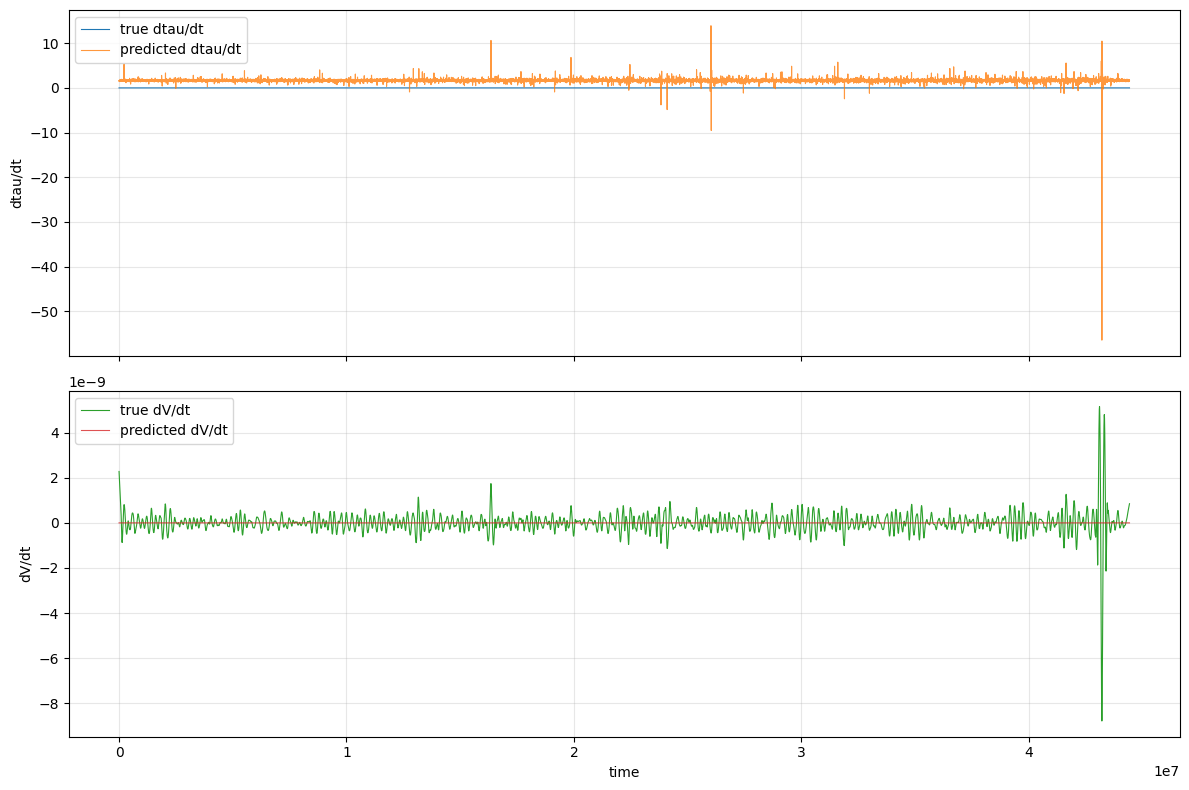

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cycle_df["time"], Xdot[:, 0], label="true dtau/dt", color="tab:blue", linewidth=0.8)
axes[0].plot(cycle_df["time"], Xdot_pred[:, 0], label="predicted dtau/dt", color="tab:orange", linewidth=0.8, alpha=0.8)
axes[0].set_ylabel("dtau/dt")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cycle_df["time"], Xdot[:, 1], label="true dV/dt", color="tab:green", linewidth=0.8)
axes[1].plot(cycle_df["time"], Xdot_pred[:, 1], label="predicted dV/dt", color="tab:red", linewidth=0.8, alpha=0.8)
axes[1].set_xlabel("time")
axes[1].set_ylabel("dV/dt")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
